# Python Notebook that is used to train and export the model for the ESP32

Install dependencies, ideally in a dedicated environment (.venv)

In [2]:
# %pip install -r requirements.txt

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow import lite as tfl

from keras import Model, Input
from keras.models import Sequential
from keras.layers import Conv1D, Dense, Dropout, AveragePooling1D, Flatten, LSTM
from keras.saving import load_model

from matplotlib import pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [4]:
RANDOM_SEED = 42

In [5]:
# load data
df = pd.read_csv('../data/aggregated2.csv')

In [6]:
# prepare data
X_flat = df.iloc[:, 1:].values
X = X_flat.reshape(-1, 100, 6)

y = df.iloc[:, 0].values
le = LabelEncoder()
y = le.fit_transform(y)
labels = le.classes_

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [7]:
# change these to what you need for the input shape

samples_per_classification = 100 # so a second of data
signal_count = 6 # the six axes of the IMU

In [8]:
# inputs and outputs of the model
input_shape = (samples_per_classification, signal_count)
num_classes = 7

In [9]:
# this is the LSTM version, may not fit on the board
def lstm_model(input_shape=input_shape, num_classes=num_classes, cells_first=64, cells_second=32) -> Model:
    lstm = Sequential()
    lstm.add(Input(shape=input_shape))
    lstm.add(LSTM(cells_first, return_sequences=True, unroll=True))
    lstm.add(Dropout(0.2))
    lstm.add(LSTM(cells_second, unroll=True))
    lstm.add(Dropout(0.2))
    lstm.add(Dense(cells_second, activation="relu"))
    lstm.add(Dense(num_classes, activation="softmax"))
    
    return lstm

In [10]:
# This is the CNN model
def cnn_model(input_shape=input_shape, num_classes=num_classes, filters=8, kernel_size=9) -> Model:
    cnn = Sequential()
    cnn.add(Input(shape=input_shape))
    cnn.add(Conv1D(filters=filters, kernel_size=kernel_size))
    cnn.add(Dropout(rate=0.2))
    cnn.add(AveragePooling1D(pool_size=5))
    cnn.add(Flatten())
    cnn.add(Dense(100, activation="relu"))
    cnn.add(Dropout(0.1))
    cnn.add(Dense(num_classes, activation="softmax"))

    return cnn

In [11]:
model = lstm_model()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 64)        │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,879 (124.53 KB)

 Trainable params: 31,879 (124.53 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 27s 130ms/step - accuracy: 0.3759 - loss: 1.6572 - val_accuracy: 0.4179 - val_loss: 1.3746
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.5027 - loss: 1.1640 - val_accuracy: 0.5125 - val_loss: 1.0424
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.5853 - loss: 0.9457 - val_accuracy: 0.5482 - val_loss: 0.9920
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.6469 - loss: 0.8389 - val_accuracy: 0.6071 - val_loss: 0.9209
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.6777 - loss: 0.7735 - val_accuracy: 0.6714 - val_loss: 0.7586
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7018 - loss: 0.7373 - val_accuracy: 0.6589 - val_loss: 0.8266
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.7339 - loss: 0.6877 - val_accuracy: 0.6804 - val_loss: 0.7424
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7214 - loss: 0.6784 - val_accuracy: 0.7125 -

KeyboardInterrupt: 

In [ ]:
def print_metrics(y_pred, y_test=y_test, model_name="base model"):
    print(f'Metrics for {model_name}')
    accuracy = 100 * accuracy_score(y_test, y_pred)
    print(f"Accuracy of model: {accuracy}%")

    f1_raw = f1_score(y_test, y_pred, average=None)
    f1_dict = {}
    for (idx, score) in enumerate(f1_raw):
        f1_dict[labels[idx]] = [score]
    f1 = pd.DataFrame.from_dict(f1_dict)
    print("F1 score per class:")
    print(f1)

    confusion = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion, display_labels=labels)

    fig, ax = plt.subplots(figsize=(12,8))
    disp.plot(ax=ax, cmap=plt.cm.Blues)
    plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 350ms/step
Metrics for base model
Accuracy of model: 84.46428571428571%
F1 score per class:
   look_down  look_left  look_right  look_up      none  tilt_left  tilt_right
0   0.898876   0.785276    0.814815     0.92  0.559322   0.925714     0.91954


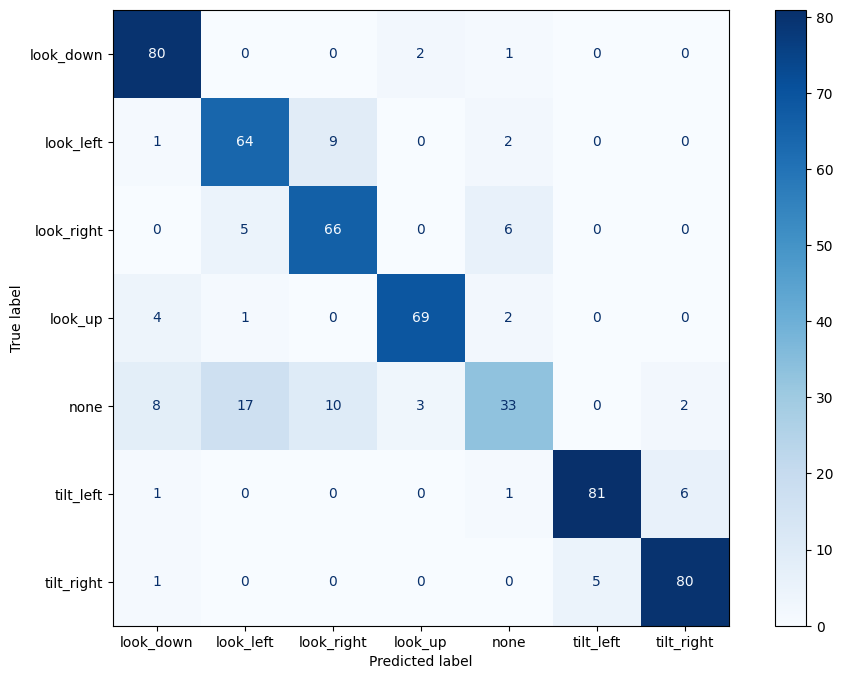

In [ ]:
# test the model
predictions = model.predict(X_test)  # Shape: (samples, num_classes)
y_pred = tf.argmax(predictions, axis=1)

print_metrics(y_pred)

In [ ]:
# change the file name if needed
model_location = 'model.h5'

In [ ]:
# save the model
model.save(model_location)

In [ ]:
# only do this cell if you want to load the existing model
model = load_model(model_location, compile=True)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 64)        │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,881 (124.54 KB)

 Trainable params: 31,879 (124.53 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Convert the model to tflite file

In [ ]:
# change the converted file name if needed
converted_location = 'model.tflite'

In [ ]:
def representative_dataset_gen():
    for i in range(len(X_test)):
        # Yield as list of float32 tensor (shape must match model input)
        yield [X_test[i:i+1].astype(np.float32)]  # Batch dim of 1

In [ ]:
def convert_model(model=model, location=converted_location, quantize=False):
    converter = tfl.TFLiteConverter.from_keras_model(model)
    if quantize:
        converter.optimizations = [tfl.Optimize.DEFAULT]
        converter.representative_dataset = representative_dataset_gen
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

    tflite_quant_model = converter.convert()
    with open(location, 'wb') as f:
        f.write(tflite_quant_model)

In [ ]:
# convert and save the model
convert_model(quantize=False)

INFO:tensorflow:Assets written to: C:\Users\Admin\AppData\Local\Temp\tmpx6pw8hg5\assets


INFO:tensorflow:Assets written to: C:\Users\Admin\AppData\Local\Temp\tmpx6pw8hg5\assets


Saved artifact at 'C:\Users\Admin\AppData\Local\Temp\tmpx6pw8hg5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 6), dtype=tf.float32, name='keras_tensor_43')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  1671223919632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1671342386704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1671342389392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1671342384976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1671342380176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1671342384400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1671537956752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1671537966160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1671537962896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1671537962512: TensorSpec(shape=(), dtype=tf.resource, name=None)


Compare performance between the original model and the quantized

c:\Users\Admin\Desktop\EMSYS\Year 1\Q3\Pervasive Computing\Pervasive_Computing_IMU_wearable_device\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Metrics for converted model
Accuracy of model: 84.46428571428571%
F1 score per class:
   look_down  look_left  look_right  look_up      none  tilt_left  tilt_right
0   0.898876   0.785276    0.814815     0.92  0.559322   0.925714     0.91954


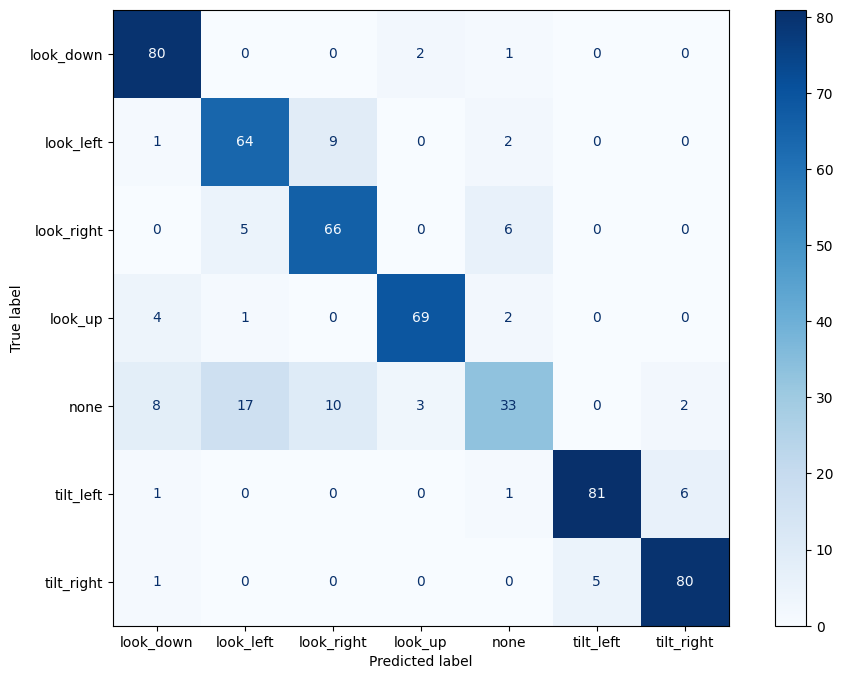

In [ ]:
interpreter = tfl.Interpreter(model_path=converted_location)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

interpreter.resize_tensor_input(input_details[0]['index'], X_test.shape)
interpreter.allocate_tensors()

interpreter.set_tensor(input_details[0]['index'], np.float32(X_test))
interpreter.invoke()

converted_pred = interpreter.get_tensor(output_details[0]['index'])
y_converted = tf.argmax(converted_pred, axis=1)

print_metrics(y_converted, model_name="converted model")


Convert tflite file to C header; make sure xxd is available in the system PATH

In [ ]:
# change the C header file name if needed
# this is what is deployed to the ESP32
header_location = "model.h"

In [ ]:
# !xxd -i {converted_location} > {header_location}

Replace the first line in the header file by these two lines (this makes it so the model is stored on PSRAM instead of DRAM)

In [ ]:
# #include <pgmspace.h>
# const unsigned char model_tflite[] PROGMEM = {

Then copy the final header into the directory with the .ino file that wants the model (esp32_LSTM currently)